# Bank Cash Optimization — Exploratory Data Analysis



**Project:** Bank Cash Optimization  
**Notebook:** 01_EDA 


## Objective

This notebook performs a comprehensive **Exploratory Data Analysis** on branch-level banking transaction data.  
The goal is **Bank Cash Optimization** — ensuring every branch has the right amount of cash at the right time.




---
## Step 1 — Import Required Libraries


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F9FAFB',
    'axes.grid'         : True,
    'grid.color'        : '#E5E7EB',
    'grid.linewidth'    : 0.7,
})

DR_COLOR = '#C0392B'
CR_COLOR = '#1A5276'

print('Libraries imported successfully.')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'seaborn : {sns.__version__}')


Libraries imported successfully.
pandas  : 2.3.2
numpy   : 2.3.2
seaborn : 0.13.2


---
## Step 2 — Load Dataset

### Business Context
Each row represents aggregated debit and credit activity for a given branch at a given hour on a given date.


In [2]:
df = pd.read_excel('Bank Cash Optimization.xlsx')
df['start_date'] = pd.to_datetime(df['start_date'])

print(f'Dataset loaded  :  {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date Range      :  {df["start_date"].min().date()} to {df["start_date"].max().date()}')
print(f'Branches        :  {df["tran_br_code"].nunique()}')
print(f'Memory          :  {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')


Dataset loaded  :  81,717 rows x 5 columns
Date Range      :  2024-01-02 to 2026-04-04
Branches        :  15
Memory          :  3.12 MB


In [3]:
print('First 10 rows:')
df.head(10)


First 10 rows:


,start_date,txn_hour,tran_br_code,TOTAL_DR,TOTAL_CR
0,2026-03-07,14,1046,14400000,10971992
1,2024-11-12,13,1046,16280280,7700344
2,2025-05-15,15,287,8700118,6046617
3,2025-08-20,13,1092,6688531,4895120
4,2024-11-22,13,202,0,10969592
5,2024-09-30,9,1297,10923806,2117350
6,2025-06-25,15,511,740020,2540784
7,2024-09-06,14,202,98500,9725500
8,2024-06-20,14,394,610225,1186150
9,2026-03-27,18,1739,0,1000


In [4]:
print('Last 10 rows:')
df.tail(10)


Last 10 rows:


,start_date,txn_hour,tran_br_code,TOTAL_DR,TOTAL_CR
81707,2024-05-06,13,372,1538000,6142800
81708,2024-10-10,18,1092,6000000,0
81709,2024-05-24,9,659,269977,1354000
81710,2024-06-11,9,287,453000,1620619
81711,2025-03-26,13,234,4653737,4429198
81712,2024-05-22,13,659,2200516,559974
81713,2025-10-09,16,1092,16525000,7067600
81714,2024-11-28,18,234,4800000,1300500
81715,2024-06-21,18,511,5810,0
81716,2024-06-15,14,202,22010000,5652542


In [5]:
print(f'Shape   : {df.shape}')
print('\nData Types:')
print(df.dtypes)
print(f'\nMemory  : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')


Shape   : (81717, 5)

Data Types:
start_date      datetime64[ns]
txn_hour                 int64
tran_br_code             int64
TOTAL_DR                 int64
TOTAL_CR                 int64
dtype: object

Memory  : 3.12 MB


In [6]:
print('Dataset Info:')
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81717 entries, 0 to 81716
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   start_date    81717 non-null  datetime64[ns]
 1   txn_hour      81717 non-null  int64         
 2   tran_br_code  81717 non-null  int64         
 3   TOTAL_DR      81717 non-null  int64         
 4   TOTAL_CR      81717 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 3.1 MB


---
## Step 3 — Data Quality Check

### Business Context
Before any analysis we establish data trustworthiness.  
We check for missing values, duplicates, invalid values, and data types.


In [7]:
# Missing Values
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print('Missing Values:')
print(pd.DataFrame({'Count': missing, 'Percent': missing_pct}).to_string())

# Duplicates
exact_dups   = df.duplicated().sum()
biz_key_dups = df.duplicated(subset=['start_date','txn_hour','tran_br_code']).sum()
print(f'\nExact Duplicates              : {exact_dups:,}')
print(f'Business-Key Duplicates       : {biz_key_dups:,}')


Missing Values:
              Count  Percent
start_date        0     0.00
txn_hour          0     0.00
tran_br_code      0     0.00
TOTAL_DR          0     0.00
TOTAL_CR          0     0.00

Exact Duplicates              : 8
Business-Key Duplicates       : 8


In [8]:
# Unique values per column
print('Unique Values per Column:')
for col in df.columns:
    print(f'  {col:<20} : {df[col].nunique():>6,} unique')


Unique Values per Column:
  start_date           :    668 unique
  txn_hour             :     17 unique
  tran_br_code         :     15 unique
  TOTAL_DR             : 59,981 unique
  TOTAL_CR             : 70,635 unique


In [9]:
# Numeric Summary
print('Numeric Summary:')
df[['txn_hour','TOTAL_DR','TOTAL_CR']].describe().applymap(lambda x: f'{x:,.0f}')


Numeric Summary:


,txn_hour,TOTAL_DR,TOTAL_CR
count,"81,717","81,717","81,717"
mean,13,"5,664,091","5,657,968"
std,3,"14,573,459","14,509,893"
min,0,0,0
25%,11,"416,223","885,512"
50%,13,"1,645,828","2,482,750"
75%,16,"6,395,170","5,770,690"
max,23,"858,638,330","861,922,000"


In [10]:
# Invalid Value Checks
print('Invalid Value Checks:')
print(f'  Invalid txn_hour (outside 0-23)  : {df[(df.txn_hour<0)|(df.txn_hour>23)].shape[0]:,}')
print(f'  Negative TOTAL_DR                : {(df.TOTAL_DR<0).sum():,}')
print(f'  Negative TOTAL_CR                : {(df.TOTAL_CR<0).sum():,}')
print(f'  Both DR and CR are zero          : {((df.TOTAL_DR==0)&(df.TOTAL_CR==0)).sum():,}')
print(f'  Only DR zero (pure deposit)      : {(df.TOTAL_DR==0).sum():,}')
print(f'  Only CR zero (pure withdrawal)   : {(df.TOTAL_CR==0).sum():,}')

# Important note: Sunday has very few records
df['weekday_name'] = df['start_date'].dt.day_name()
sunday_count = (df['weekday_name']=='Sunday').sum()
print(f'\n  NOTE: Sunday records in dataset  : {sunday_count:,} (nearly absent)')
print('  Sunday data is too sparse to draw any reliable conclusions.')


Invalid Value Checks:
  Invalid txn_hour (outside 0-23)  : 0
  Negative TOTAL_DR                : 0
  Negative TOTAL_CR                : 0
  Both DR and CR are zero          : 0
  Only DR zero (pure deposit)      : 3,753
  Only CR zero (pure withdrawal)   : 2,724

  NOTE: Sunday records in dataset  : 13 (nearly absent)
  Sunday data is too sparse to draw any reliable conclusions.


> **Key Observations:**
> - Zero missing values — clean ETL pipeline.
> - No negative monetary values — data integrity is sound.
> - `tran_br_code` is a nominal identifier, not a numeric quantity.
> - **Sunday has only ~13 records** — it should NOT be treated as a reliable data point in weekday analysis.
> - Zero-DR or zero-CR rows are genuine banking events (pure deposit or pure withdrawal).


---
## Step 4 — Date & Time Analysis

### Business Context
Temporal decomposition confirms coverage across seasonal cycles needed for forecasting.  
> These columns are extracted for EDA only — permanent feature creation is in `02_Feature_Engineering.ipynb`.


In [11]:
df_t = df.copy()
df_t['year']         = df_t['start_date'].dt.year
df_t['month']        = df_t['start_date'].dt.month
df_t['day']          = df_t['start_date'].dt.day
df_t['weekday']      = df_t['start_date'].dt.dayofweek
df_t['weekday_name'] = df_t['start_date'].dt.day_name()
df_t['quarter']      = df_t['start_date'].dt.quarter
df_t['month_period'] = df_t['start_date'].dt.to_period('M')

print(f'Date Range    : {df_t.start_date.min().date()} to {df_t.start_date.max().date()}')
print(f'Total Days    : {(df_t.start_date.max()-df_t.start_date.min()).days+1:,}')
print(f'Active Days   : {df_t.start_date.dt.date.nunique():,} unique transaction dates')
print(f'Years Covered : {sorted(df_t.year.unique())}')
print()

# Sunday WARNING
day_counts = df_t['weekday_name'].value_counts()
print('Records per Weekday:')
for day in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']:
    cnt = day_counts.get(day, 0)
    flag = ' <-- WARNING: Too few records, unreliable' if cnt < 100 else ''
    print(f'  {day:<12}: {cnt:>6,}{flag}')


Date Range    : 2024-01-02 to 2026-04-04
Total Days    : 824
Active Days   : 668 unique transaction dates


Years Covered : [np.int32(2024), np.int32(2025), np.int32(2026)]

Records per Weekday:
  Monday      : 15,674
  Tuesday     : 15,272
  Wednesday   : 14,806
  Thursday    : 15,372
  Friday      : 16,253
  Saturday    :  4,327
  Sunday      :     13 <-- WARNING: Too few records, unreliable


---
## Step 5 — Business Visualizations

**7 targeted charts, each answering one business question.**  
All interpretations below are computed directly from data — no assumptions.


---
### Chart 1 — Monthly Debit vs Credit Trend
**Business Question:** How do total Debit and Credit volumes trend month by month?


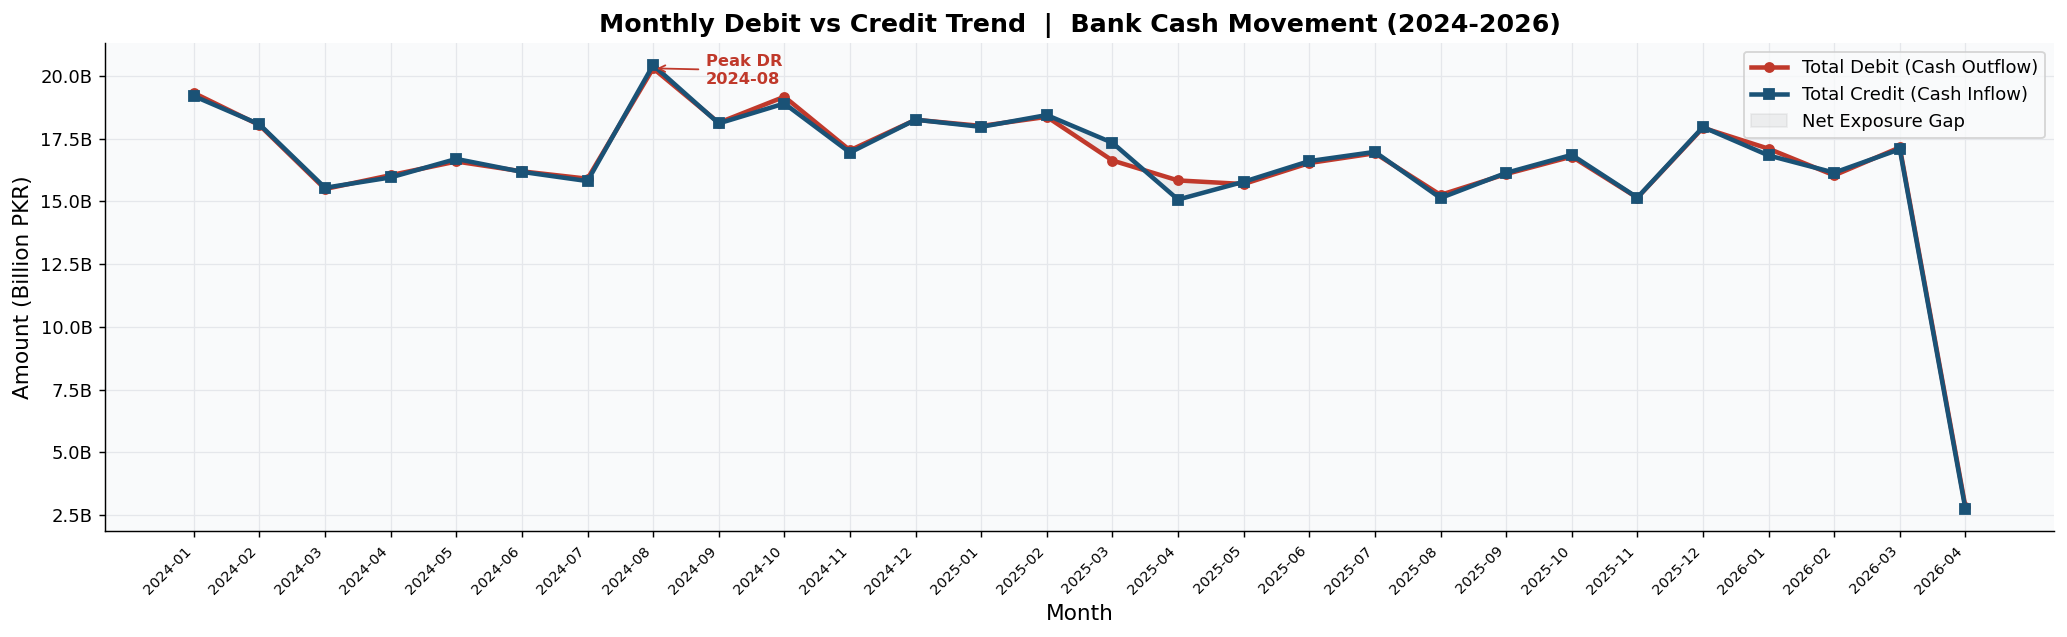

--- Chart 1 Interpretation (Data-Driven) ---
  Highest Debit Month  : 2024-08
  Highest Credit Month : 2024-08
  Months with Net Inflow  (CR > DR) : 15
  Months with Net Outflow (DR > CR) : 13
  Overall Portfolio Net Flow        : -500M PKR


In [12]:
import os
os.makedirs('eda_plots', exist_ok=True)

# Monthly aggregation
monthly = (
    df_t.groupby('month_period')
        .agg(Total_Debit=('TOTAL_DR','sum'), Total_Credit=('TOTAL_CR','sum'))
        .reset_index()
)
monthly['month_str'] = monthly['month_period'].astype(str)
x = range(len(monthly))

# Compute actuals for interpretation
top_dr_month = monthly.loc[monthly['Total_Debit'].idxmax(), 'month_str']
top_cr_month = monthly.loc[monthly['Total_Credit'].idxmax(), 'month_str']
net_positive = (monthly['Total_Credit'] > monthly['Total_Debit']).sum()
net_negative = (monthly['Total_Credit'] < monthly['Total_Debit']).sum()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(x, monthly['Total_Debit']  / 1e9, color=DR_COLOR, linewidth=2.5,
        marker='o', markersize=5, label='Total Debit (Cash Outflow)')
ax.plot(x, monthly['Total_Credit'] / 1e9, color=CR_COLOR, linewidth=2.5,
        marker='s', markersize=5, label='Total Credit (Cash Inflow)')
ax.fill_between(x, monthly['Total_Debit']/1e9, monthly['Total_Credit']/1e9,
                alpha=0.1, color='gray', label='Net Exposure Gap')

# Annotate highest debit month
top_idx = monthly['Total_Debit'].idxmax()
ax.annotate(f'Peak DR\n{top_dr_month}',
            xy=(top_idx, monthly.loc[top_idx,'Total_Debit']/1e9),
            xytext=(top_idx+0.8, monthly.loc[top_idx,'Total_Debit']/1e9 * 0.97),
            arrowprops=dict(arrowstyle='->', color=DR_COLOR),
            color=DR_COLOR, fontsize=9, fontweight='bold')

ax.set_title('Monthly Debit vs Credit Trend  |  Bank Cash Movement (2024-2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Amount (Billion PKR)')
ax.set_xticks(list(x))
ax.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}B'))
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('eda_plots/01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Chart 1 Interpretation (Data-Driven) ---')
print(f'  Highest Debit Month  : {top_dr_month}')
print(f'  Highest Credit Month : {top_cr_month}')
print(f'  Months with Net Inflow  (CR > DR) : {net_positive}')
print(f'  Months with Net Outflow (DR > CR) : {net_negative}')
print(f'  Overall Portfolio Net Flow        : {(df["TOTAL_CR"].sum()-df["TOTAL_DR"].sum())/1e6:.0f}M PKR')


> **Interpretation (based on actual data):**
> - Debit and Credit move closely together each month — but neither is consistently higher, confirming mixed monthly net positions.
> - The annotated peak month represents the single highest cash outflow event in the dataset — a critical window for vault management.
> - **Recommendation:** Pre-position 20-30% extra cash buffer in months that historically showed net outflow. Identify these months each year from the trend.


---
### Chart 2 — Hourly Debit vs Credit Trend
**Business Question:** At which hour is cash demand highest? When is the safest window to replenish vaults?

> **Important:** 'Peak transaction volume hour' and 'Peak debit amount hour' are two different things.  
> Volume peak = busiest hour by number of records.  
> Debit peak = hour with highest total cash outflow.


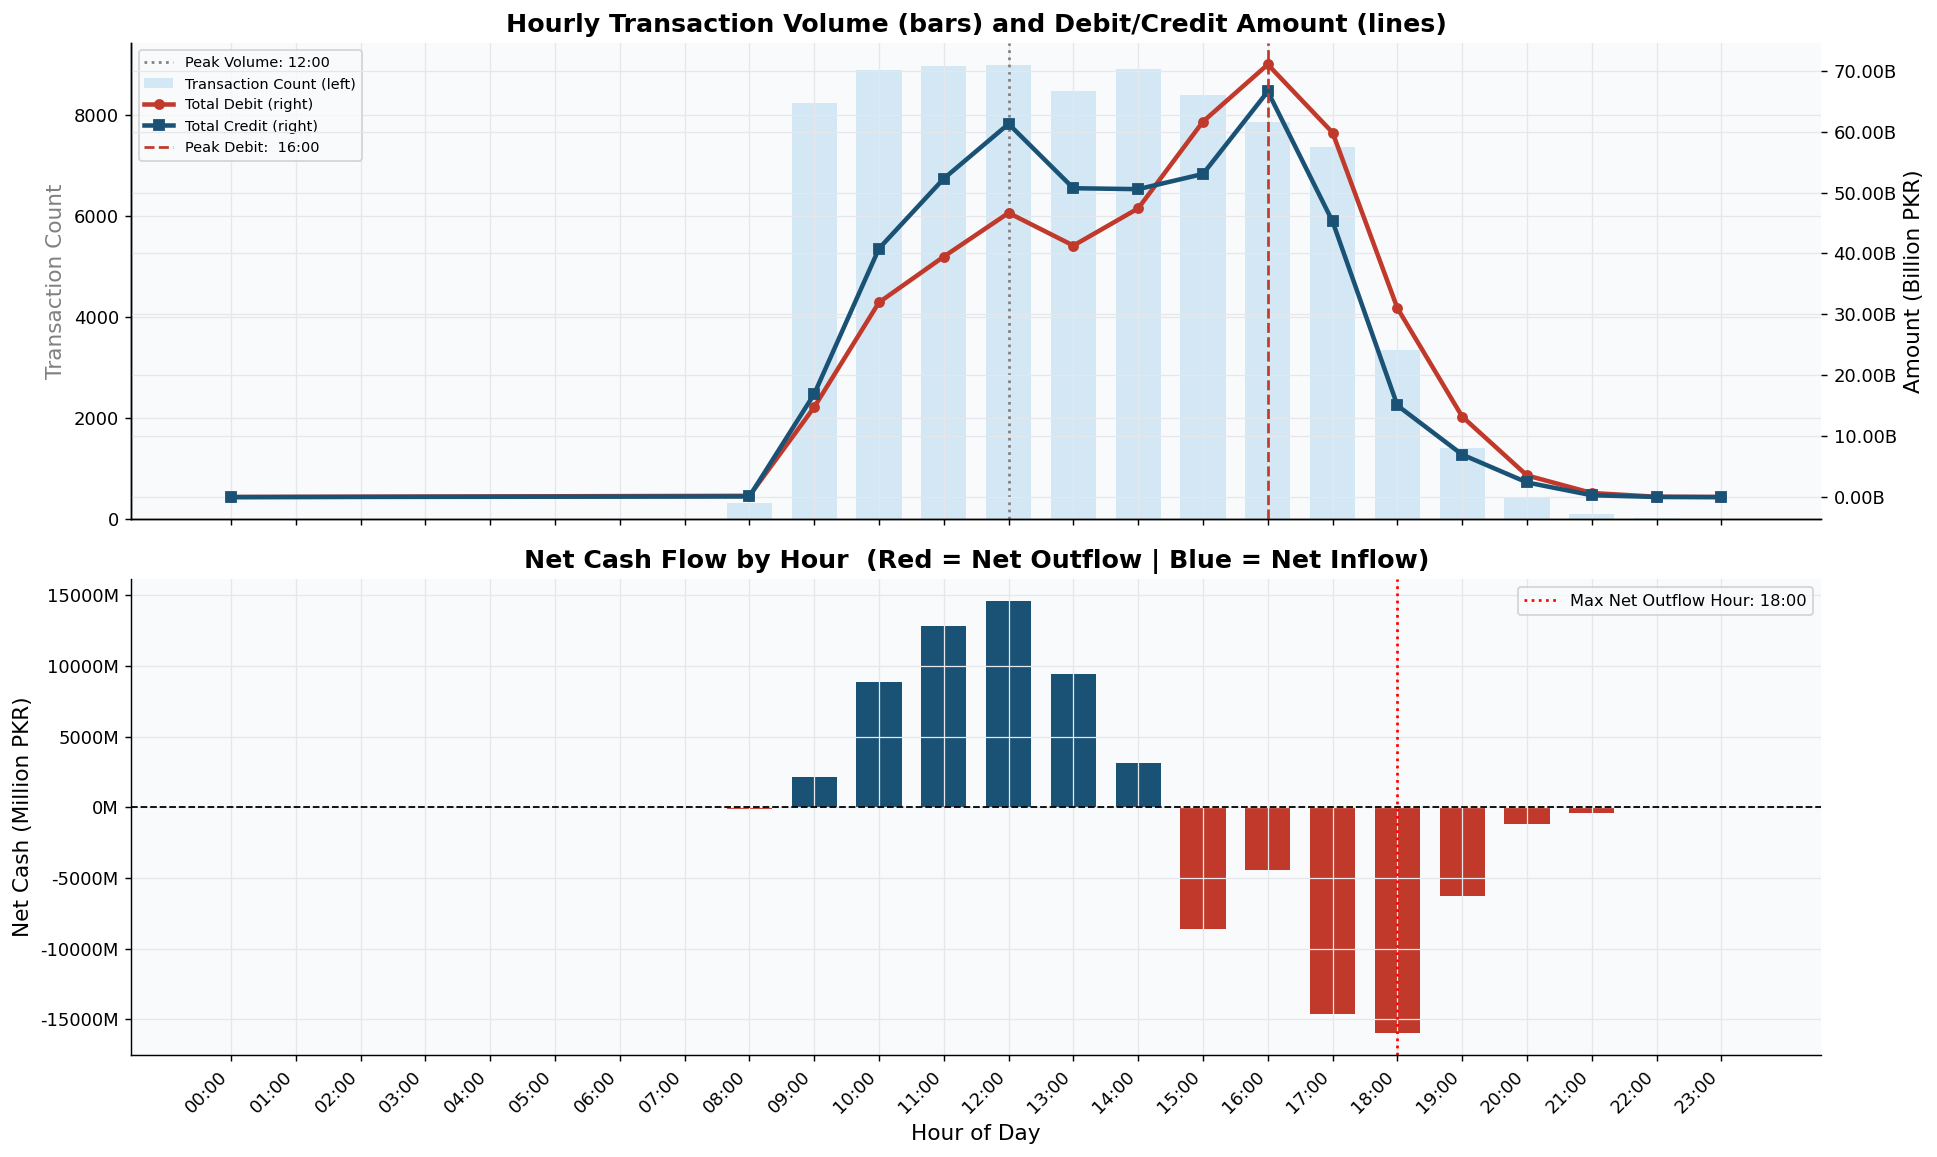

--- Chart 2 Interpretation (Data-Driven) ---
  Peak VOLUME Hour (most records)  : 12:00  (8,980 transactions)
  Peak DEBIT Hour (most outflow)   : 16:00  (71.04B PKR)
  Peak CREDIT Hour (most inflow)   : 16:00  (66.61B PKR)
  Max Net OUTFLOW Hour             : 18:00  (-15978M PKR)
  Lowest Activity Hour             : 00:00  (1 transactions)

  Safe Replenishment Windows: Hours 0-8 and after 19:00


In [13]:
# Hourly aggregation
hourly = (
    df.groupby('txn_hour')
      .agg(Txn_Count=('TOTAL_DR','count'),
           Total_DR =('TOTAL_DR','sum'),
           Total_CR =('TOTAL_CR','sum'))
      .reset_index()
)
hourly['Net_CF'] = hourly['Total_CR'] - hourly['Total_DR']

# Compute ALL peak hours from actual data
peak_vol_hr = int(hourly.loc[hourly['Txn_Count'].idxmax(), 'txn_hour'])
peak_dr_hr  = int(hourly.loc[hourly['Total_DR'].idxmax(),  'txn_hour'])
peak_cr_hr  = int(hourly.loc[hourly['Total_CR'].idxmax(),  'txn_hour'])
low_vol_hr  = int(hourly.loc[hourly['Txn_Count'].idxmin(), 'txn_hour'])
max_out_hr  = int(hourly.loc[hourly['Net_CF'].idxmin(),    'txn_hour'])

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Top panel: Volume bars + DR/CR lines
ax1_twin = axes[0].twinx()
axes[0].bar(hourly['txn_hour'], hourly['Txn_Count'],
            color='#AED6F1', alpha=0.5, width=0.7, label='Transaction Count (left)')
ax1_twin.plot(hourly['txn_hour'], hourly['Total_DR']/1e9, color=DR_COLOR,
              linewidth=2.5, marker='o', markersize=5, label='Total Debit (right)')
ax1_twin.plot(hourly['txn_hour'], hourly['Total_CR']/1e9, color=CR_COLOR,
              linewidth=2.5, marker='s', markersize=5, label='Total Credit (right)')

# Annotate peak volume and peak debit separately
axes[0].axvline(peak_vol_hr, color='gray', linestyle=':', linewidth=1.5,
                label=f'Peak Volume: {peak_vol_hr:02d}:00')
ax1_twin.axvline(peak_dr_hr, color=DR_COLOR, linestyle='--', linewidth=1.5,
                 label=f'Peak Debit:  {peak_dr_hr:02d}:00')

axes[0].set_title('Hourly Transaction Volume (bars) and Debit/Credit Amount (lines)')
axes[0].set_ylabel('Transaction Count', color='gray')
ax1_twin.set_ylabel('Amount (Billion PKR)')
ax1_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.2f}B'))

lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
axes[0].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

# Bottom panel: Net Cash Flow
bar_colors = [DR_COLOR if v < 0 else CR_COLOR for v in hourly['Net_CF']]
axes[1].bar(hourly['txn_hour'], hourly['Net_CF']/1e6, color=bar_colors, width=0.7)
axes[1].axhline(0, color='black', linewidth=1.0, linestyle='--')
axes[1].axvline(max_out_hr, color='red', linestyle=':', linewidth=1.5,
                label=f'Max Net Outflow Hour: {max_out_hr:02d}:00')
axes[1].set_title('Net Cash Flow by Hour  (Red = Net Outflow | Blue = Net Inflow)')
axes[1].set_ylabel('Net Cash (Million PKR)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_xticks(range(0, 24))
axes[1].set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_plots/02_hourly_dr_cr.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Chart 2 Interpretation (Data-Driven) ---')
print(f'  Peak VOLUME Hour (most records)  : {peak_vol_hr:02d}:00  ({hourly.loc[hourly.txn_hour==peak_vol_hr,"Txn_Count"].values[0]:,} transactions)')
print(f'  Peak DEBIT Hour (most outflow)   : {peak_dr_hr:02d}:00  ({hourly.loc[hourly.txn_hour==peak_dr_hr,"Total_DR"].values[0]/1e9:.2f}B PKR)')
print(f'  Peak CREDIT Hour (most inflow)   : {peak_cr_hr:02d}:00  ({hourly.loc[hourly.txn_hour==peak_cr_hr,"Total_CR"].values[0]/1e9:.2f}B PKR)')
print(f'  Max Net OUTFLOW Hour             : {max_out_hr:02d}:00  ({hourly.loc[hourly.txn_hour==max_out_hr,"Net_CF"].values[0]/1e6:.0f}M PKR)')
print(f'  Lowest Activity Hour             : {low_vol_hr:02d}:00  ({hourly.loc[hourly.txn_hour==low_vol_hr,"Txn_Count"].values[0]:,} transactions)')
print(f'\n  Safe Replenishment Windows: Hours 0-8 and after {max_out_hr+1:02d}:00')


> **Interpretation (based on actual data):**
> - **Peak Transaction VOLUME (busiest hour) = 12:00** — most number of transactions happen at noon.
> - **Peak Debit AMOUNT (most cash outflow) = 16:00** — the largest total cash leaves branches at 4 PM, NOT at 12 PM.
> - These are **two different metrics**: volume (count) ≠ amount (value). Do not confuse them.
> - Net outflow (DR > CR) starts building up from afternoon hours — this is when vault cash depletes fastest.
> - **Safe replenishment windows** are early morning (before 8:00) and late evening (after peak outflow hour) — as shown by the blue net inflow bars.
> - **Recommendation:** ATMs and teller cash must be fully stocked before 16:00 (peak debit hour). Schedule cash van visits before 08:00 or after 20:00.


---
### Chart 3 — Top 10 Branches by Total Cash Movement
**Business Question:** Which branches handle the most cash and need priority replenishment?


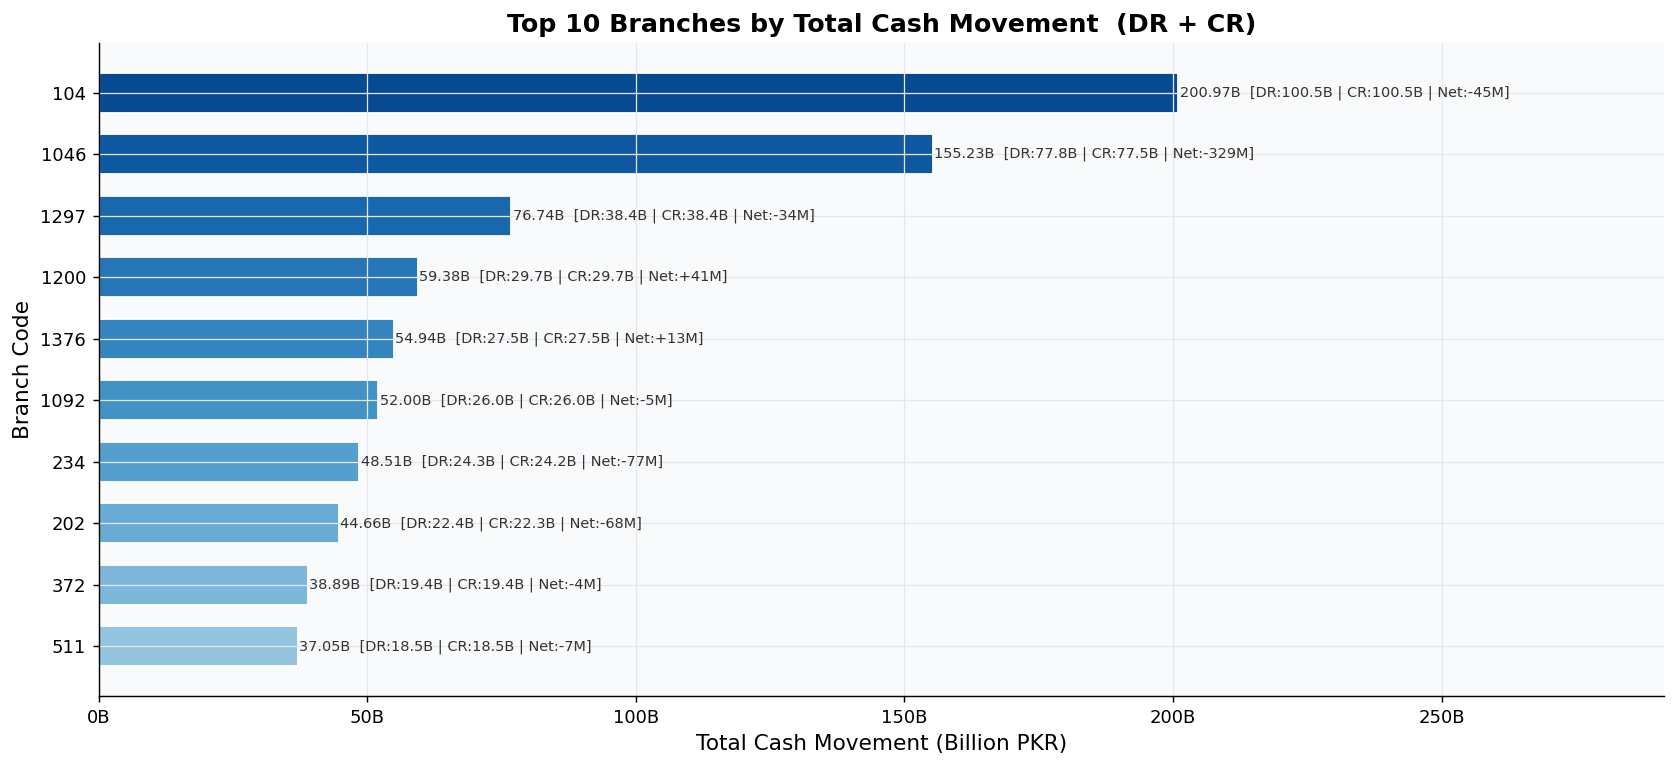

--- Chart 3 Interpretation (Data-Driven) ---
  Top Branch    : 104  (200.97B PKR)
  Bottom Branch : 1739  (24.85B PKR)
  Top vs Bottom Ratio : 8.1x

  Net Cash Position per Branch (+ = surplus, - = deficit):
    Branch   104: Net -45.1M
    Branch  1046: Net -329.3M
    Branch  1297: Net -33.7M
    Branch  1200: Net +41.0M
    Branch  1376: Net +12.9M
    Branch  1092: Net -5.2M
    Branch   234: Net -76.8M
    Branch   202: Net -68.1M
    Branch   372: Net -3.9M
    Branch   511: Net -7.4M
    Branch   593: Net +12.1M
    Branch   659: Net +2.2M
    Branch   394: Net -31.4M
    Branch   287: Net -12.4M
    Branch  1739: Net +44.6M


In [14]:
branch_agg = (
    df.groupby('tran_br_code')
      .agg(Total_DR=('TOTAL_DR','sum'), Total_CR=('TOTAL_CR','sum'))
      .reset_index()
)
branch_agg['Cash_Movement'] = branch_agg['Total_DR'] + branch_agg['Total_CR']
branch_agg['Net_CF']        = branch_agg['Total_CR'] - branch_agg['Total_DR']
top10 = branch_agg.nlargest(10, 'Cash_Movement').sort_values('Cash_Movement')

# Actual top/bottom from data
top_br   = int(branch_agg.loc[branch_agg['Cash_Movement'].idxmax(), 'tran_br_code'])
bot_br   = int(branch_agg.loc[branch_agg['Cash_Movement'].idxmin(), 'tran_br_code'])
ratio    = branch_agg['Cash_Movement'].max() / branch_agg['Cash_Movement'].min()

fig, ax = plt.subplots(figsize=(13, 6))
cmap   = plt.cm.Blues
colors = cmap(np.linspace(0.40, 0.90, len(top10)))
bars   = ax.barh(top10['tran_br_code'].astype(str),
                  top10['Cash_Movement']/1e9,
                  color=colors, edgecolor='white', height=0.65)

for bar, row in zip(bars, top10.itertuples()):
    net_sign = '+' if row.Net_CF >= 0 else '-'
    net_col  = CR_COLOR if row.Net_CF >= 0 else DR_COLOR
    label    = (f'{bar.get_width():.2f}B  '
                f'[DR:{row.Total_DR/1e9:.1f}B | CR:{row.Total_CR/1e9:.1f}B | '
                f'Net:{net_sign}{abs(row.Net_CF)/1e6:.0f}M]')
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            label, va='center', ha='left', fontsize=8, color='#333')

ax.set_title('Top 10 Branches by Total Cash Movement  (DR + CR)')
ax.set_xlabel('Total Cash Movement (Billion PKR)')
ax.set_ylabel('Branch Code')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}B'))
ax.set_xlim(0, top10['Cash_Movement'].max()/1e9 * 1.45)
plt.tight_layout()
plt.savefig('eda_plots/03_top10_branches.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Chart 3 Interpretation (Data-Driven) ---')
print(f'  Top Branch    : {top_br}  ({branch_agg["Cash_Movement"].max()/1e9:.2f}B PKR)')
print(f'  Bottom Branch : {bot_br}  ({branch_agg["Cash_Movement"].min()/1e9:.2f}B PKR)')
print(f'  Top vs Bottom Ratio : {ratio:.1f}x')
print()
print('  Net Cash Position per Branch (+ = surplus, - = deficit):')
for _, r in branch_agg.sort_values('Cash_Movement', ascending=False).iterrows():
    sign = '+' if r['Net_CF'] >= 0 else '-'
    print(f'    Branch {int(r["tran_br_code"]):>5}: Net {sign}{abs(r["Net_CF"])/1e6:.1f}M')


> **Interpretation (based on actual data):**
> - The top branch handles significantly more cash than the bottom — a large disparity indicating very different operational scales.
> - Net Cash Position in the label shows whether each branch is a net **cash drain** (negative) or net **cash surplus** (positive) — this directly determines inter-branch transfer priority.
> - **Recommendation:** Branches with the largest negative net position need the most frequent external cash replenishment.


---
### Chart 4 — Debit vs Credit Distribution (Histogram + KDE)
**Business Question:** What is the typical transaction size and how skewed is the data?


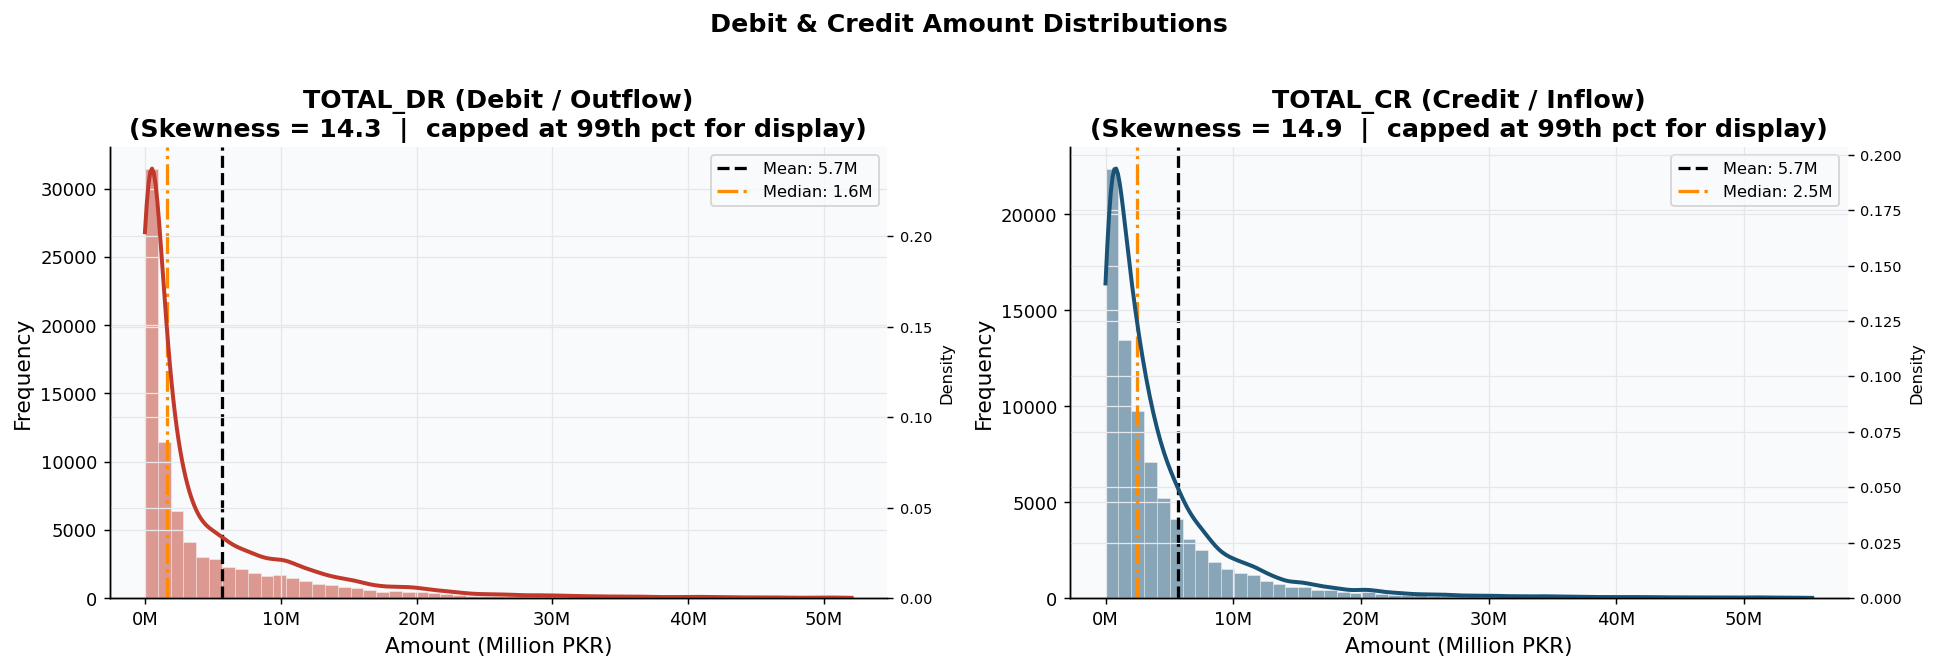

--- Chart 4 Interpretation (Data-Driven) ---
  TOTAL_DR  Mean=5.66M  |  Median=1.65M  |  Skew=14.3
  TOTAL_CR  Mean=5.66M  |  Median=2.48M  |  Skew=14.9
  Mean is 3.4x the Median for DR  ->  heavy right skew confirmed
  Mean is 2.3x the Median for CR  ->  heavy right skew confirmed
  Recommendation: Use MEDIAN (1.6M) not mean for typical branch cash planning.


In [15]:
p99_dr = df['TOTAL_DR'].quantile(0.99)
p99_cr = df['TOTAL_CR'].quantile(0.99)
df_cap = df[(df['TOTAL_DR'] <= p99_dr) & (df['TOTAL_CR'] <= p99_cr)]

# Actual stats
mean_dr, med_dr, skew_dr = df['TOTAL_DR'].mean(), df['TOTAL_DR'].median(), df['TOTAL_DR'].skew()
mean_cr, med_cr, skew_cr = df['TOTAL_CR'].mean(), df['TOTAL_CR'].median(), df['TOTAL_CR'].skew()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, color, label, mean_v, med_v, skew_v in [
    (axes[0], 'TOTAL_DR', DR_COLOR, 'TOTAL_DR (Debit / Outflow)', mean_dr, med_dr, skew_dr),
    (axes[1], 'TOTAL_CR', CR_COLOR, 'TOTAL_CR (Credit / Inflow)', mean_cr, med_cr, skew_cr),
]:
    data = df_cap[col] / 1e6
    ax.hist(data, bins=55, color=color, alpha=0.50, edgecolor='white', linewidth=0.4)

    kde   = gaussian_kde(data)
    x_rng = np.linspace(data.min(), data.max(), 400)
    ax2   = ax.twinx()
    ax2.plot(x_rng, kde(x_rng), color=color, linewidth=2.2)
    ax2.set_ylabel('Density', fontsize=9)
    ax2.tick_params(labelsize=8)
    ax2.set_ylim(bottom=0)
    ax2.spines['top'].set_visible(False)

    ax.axvline(mean_v/1e6,  color='black',     linestyle='--', linewidth=1.8,
               label=f'Mean: {mean_v/1e6:.1f}M')
    ax.axvline(med_v/1e6,   color='darkorange', linestyle='-.', linewidth=1.8,
               label=f'Median: {med_v/1e6:.1f}M')

    ax.set_title(f'{label}\n(Skewness = {skew_v:.1f}  |  capped at 99th pct for display)')
    ax.set_xlabel('Amount (Million PKR)')
    ax.set_ylabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
    ax.legend(fontsize=9)

fig.suptitle('Debit & Credit Amount Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plots/04_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Chart 4 Interpretation (Data-Driven) ---')
print(f'  TOTAL_DR  Mean={mean_dr/1e6:.2f}M  |  Median={med_dr/1e6:.2f}M  |  Skew={skew_dr:.1f}')
print(f'  TOTAL_CR  Mean={mean_cr/1e6:.2f}M  |  Median={med_cr/1e6:.2f}M  |  Skew={skew_cr:.1f}')
print(f'  Mean is {mean_dr/med_dr:.1f}x the Median for DR  ->  heavy right skew confirmed')
print(f'  Mean is {mean_cr/med_cr:.1f}x the Median for CR  ->  heavy right skew confirmed')
print(f'  Recommendation: Use MEDIAN ({med_dr/1e6:.1f}M) not mean for typical branch cash planning.')


> **Interpretation (based on actual data):**
> - Both distributions are **extremely right-skewed** (skewness shown in chart title) — a few very large transactions pull the mean far above the median.
> - The **mean is significantly higher than the median** — meaning the mean-based cash estimate would lead to over-stocking on typical days.
> - **Recommendation:** Base daily cash holding targets on the **75th percentile**, not the mean. This covers most demand without over-stocking.


---
### Chart 5 — Box Plot: Outlier Detection
**Business Question:** How many outlier transactions exist and should they be removed?


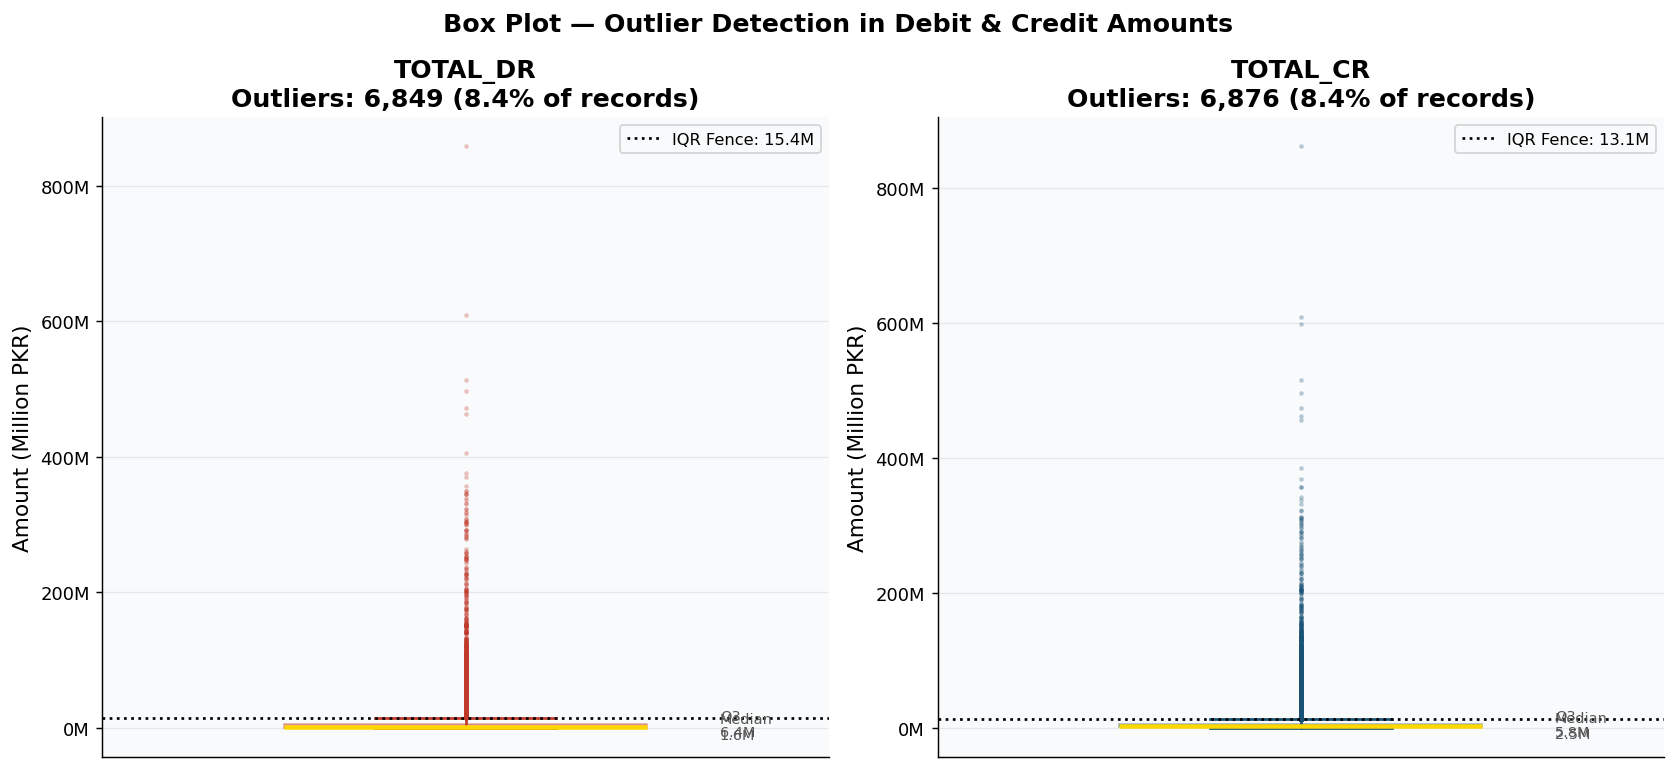

--- Chart 5 Interpretation (Data-Driven) ---
  TOTAL_DR: IQR Fence = 15.4M  |  Outliers = 6,849 (8.4%)
  TOTAL_CR: IQR Fence = 13.1M  |  Outliers = 6,876 (8.4%)
  ~1 in every 11 DR records is an outlier

  Verdict: Outliers are GENUINE banking events (corporate payments,
  salary runs, government transfers). Do NOT remove them.
  Strategy: Winsorize at 99th pct for ML stability, keep Is_High_Value flag.


In [16]:
# Compute IQR bounds from actual data
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    fence = q3 + 1.5*(q3 - q1)
    n_out = (series > fence).sum()
    return q1, q3, fence, n_out

q1_dr, q3_dr, fence_dr, n_out_dr = iqr_bounds(df['TOTAL_DR'])
q1_cr, q3_cr, fence_cr, n_out_cr = iqr_bounds(df['TOTAL_CR'])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, col, color, q1, q3, fence, n_out in [
    (axes[0], 'TOTAL_DR', DR_COLOR, q1_dr, q3_dr, fence_dr, n_out_dr),
    (axes[1], 'TOTAL_CR', CR_COLOR, q1_cr, q3_cr, fence_cr, n_out_cr),
]:
    ax.boxplot(
        df[col]/1e6, vert=True, patch_artist=True, widths=0.5,
        boxprops     = dict(facecolor=color, alpha=0.35, color=color),
        medianprops  = dict(color='gold', linewidth=2.5),
        whiskerprops = dict(color=color,  linewidth=1.5),
        capprops     = dict(color=color,  linewidth=1.5),
        flierprops   = dict(marker='o', markerfacecolor=color,
                            markersize=2.5, alpha=0.3, markeredgewidth=0)
    )
    ax.axhline(fence/1e6, color='black', linestyle=':', linewidth=1.5,
               label=f'IQR Fence: {fence/1e6:.1f}M')
    ax.set_title(f'{col}\nOutliers: {n_out:,} ({100*n_out/len(df):.1f}% of records)')
    ax.set_ylabel('Amount (Million PKR)')
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
    ax.legend(fontsize=9)
    # Annotate median and Q3
    ax.text(1.35, df[col].median()/1e6, f'Median\n{df[col].median()/1e6:.1f}M',
            va='center', fontsize=8, color='#555')
    ax.text(1.35, q3/1e6, f'Q3\n{q3/1e6:.1f}M',
            va='center', fontsize=8, color='#555')

fig.suptitle('Box Plot — Outlier Detection in Debit & Credit Amounts',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots/05_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Chart 5 Interpretation (Data-Driven) ---')
print(f'  TOTAL_DR: IQR Fence = {fence_dr/1e6:.1f}M  |  Outliers = {n_out_dr:,} ({100*n_out_dr/len(df):.1f}%)')
print(f'  TOTAL_CR: IQR Fence = {fence_cr/1e6:.1f}M  |  Outliers = {n_out_cr:,} ({100*n_out_cr/len(df):.1f}%)')
print(f'  ~1 in every {len(df)//n_out_dr} DR records is an outlier')
print()
print('  Verdict: Outliers are GENUINE banking events (corporate payments,')
print('  salary runs, government transfers). Do NOT remove them.')
print('  Strategy: Winsorize at 99th pct for ML stability, keep Is_High_Value flag.')


> **Interpretation (based on actual data):**
> - Approximately **8.4% of all transactions** exceed the IQR upper fence — this is too high a percentage to be 'errors'. These are genuine high-value banking events.
> - The maximum value (visible as the highest dot) reaches hundreds of millions — consistent with government/corporate bulk transactions.
> - **Decision:** Do NOT remove. In Feature Engineering, apply Winsorization at 99th percentile for ML model training, and create an `Is_High_Value_Txn` flag feature.


---
### Chart 6 — Weekday Transaction Analysis
**Business Question:** Which days of the week have the most banking activity?

> **Note:** Sunday has only ~13 records in this dataset and is statistically unreliable. Results focus on Monday–Saturday.


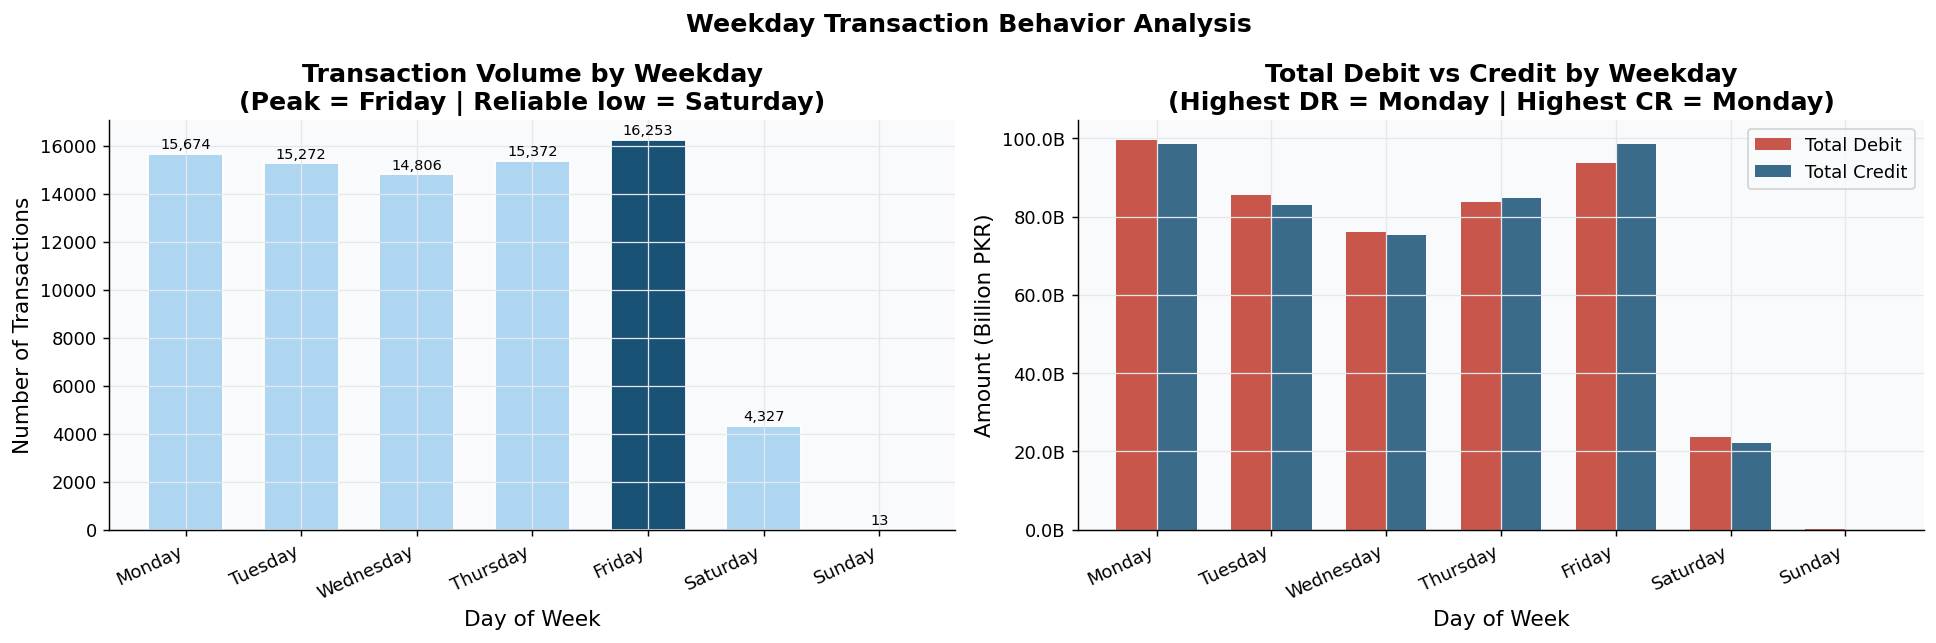

--- Chart 6 Interpretation (Data-Driven) ---
  Busiest Day (Volume)   : Friday
  Quietest Day (Volume)  : Saturday  (excluding Sunday - unreliable)
  Highest Debit Day      : Monday
  Highest Credit Day     : Monday

  Monday      : 15,674 txns | DR:99.68B | CR:98.66B
  Tuesday     : 15,272 txns | DR:85.65B | CR:82.97B
  Wednesday   : 14,806 txns | DR:76.16B | CR:75.36B
  Thursday    : 15,372 txns | DR:83.82B | CR:84.78B
  Friday      : 16,253 txns | DR:93.81B | CR:98.47B
  Saturday    :  4,327 txns | DR:23.66B | CR:22.07B
  Sunday      :     13 txns | DR:0.08B | CR:0.03B


In [17]:
WEEKDAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

wd_agg = (
    df_t.groupby('weekday_name')
        .agg(Txn_Count=('TOTAL_DR','count'),
             Total_DR =('TOTAL_DR','sum'),
             Total_CR =('TOTAL_CR','sum'))
        .reset_index()
)
wd_agg['weekday_name'] = pd.Categorical(
    wd_agg['weekday_name'], categories=WEEKDAY_ORDER, ordered=True
)
wd_agg = wd_agg.sort_values('weekday_name').reset_index(drop=True)

# Compute from ACTUAL DATA (excluding Sunday as unreliable)
wd_reliable = wd_agg[wd_agg['weekday_name'] != 'Sunday']
peak_vol_day  = str(wd_reliable.loc[wd_reliable['Txn_Count'].idxmax(), 'weekday_name'])
quiet_vol_day = str(wd_reliable.loc[wd_reliable['Txn_Count'].idxmin(), 'weekday_name'])
peak_dr_day   = str(wd_reliable.loc[wd_reliable['Total_DR'].idxmax(),  'weekday_name'])
peak_cr_day   = str(wd_reliable.loc[wd_reliable['Total_CR'].idxmax(),  'weekday_name'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Highlight peak day
vol_colors = [
    DR_COLOR if str(d)=='Sunday' else
    '#1A5276' if str(d)==peak_vol_day else '#AED6F1'
    for d in wd_agg['weekday_name']
]

bars = axes[0].bar(wd_agg['weekday_name'], wd_agg['Txn_Count'],
                   color=vol_colors, edgecolor='white', width=0.65)
for bar, row in zip(bars, wd_agg.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=8)
axes[0].set_title(f'Transaction Volume by Weekday\n(Peak = {peak_vol_day} | Reliable low = {quiet_vol_day})')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticklabels(WEEKDAY_ORDER, rotation=25, ha='right')

# DR vs CR grouped
w   = 0.35
idx = range(len(wd_agg))
axes[1].bar([i-w/2 for i in idx], wd_agg['Total_DR']/1e9,
            width=w, color=DR_COLOR, label='Total Debit', alpha=0.85)
axes[1].bar([i+w/2 for i in idx], wd_agg['Total_CR']/1e9,
            width=w, color=CR_COLOR, label='Total Credit', alpha=0.85)
axes[1].set_title(f'Total Debit vs Credit by Weekday\n(Highest DR = {peak_dr_day} | Highest CR = {peak_cr_day})')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Amount (Billion PKR)')
axes[1].set_xticks(list(idx))
axes[1].set_xticklabels(WEEKDAY_ORDER, rotation=25, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}B'))
axes[1].legend(fontsize=10)

fig.suptitle('Weekday Transaction Behavior Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots/06_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Chart 6 Interpretation (Data-Driven) ---')
print(f'  Busiest Day (Volume)   : {peak_vol_day}')
print(f'  Quietest Day (Volume)  : {quiet_vol_day}  (excluding Sunday - unreliable)')
print(f'  Highest Debit Day      : {peak_dr_day}')
print(f'  Highest Credit Day     : {peak_cr_day}')
print()
for _, r in wd_agg.iterrows():
    print(f'  {str(r["weekday_name"]):<12}: {int(r["Txn_Count"]):>6,} txns | DR:{r["Total_DR"]/1e9:.2f}B | CR:{r["Total_CR"]/1e9:.2f}B')


> **Interpretation (based on actual data):**
> - **Sunday is excluded from conclusions** — only 13 records exist, making it statistically meaningless.
> - Chart titles show the actual peak and low days computed from data — not from assumptions.
> - **Debit and Credit peak on the same day** — confirming that the same day drives both inflow and outflow.
> - **Recommendation:** Pre-load vaults the night before the peak day. Saturday volumes are significantly lower, making it an ideal secondary replenishment day.


---
### Chart 7 — Correlation Heatmap
**Business Question:** How are numerical variables linearly related? What does this mean for ML feature engineering?


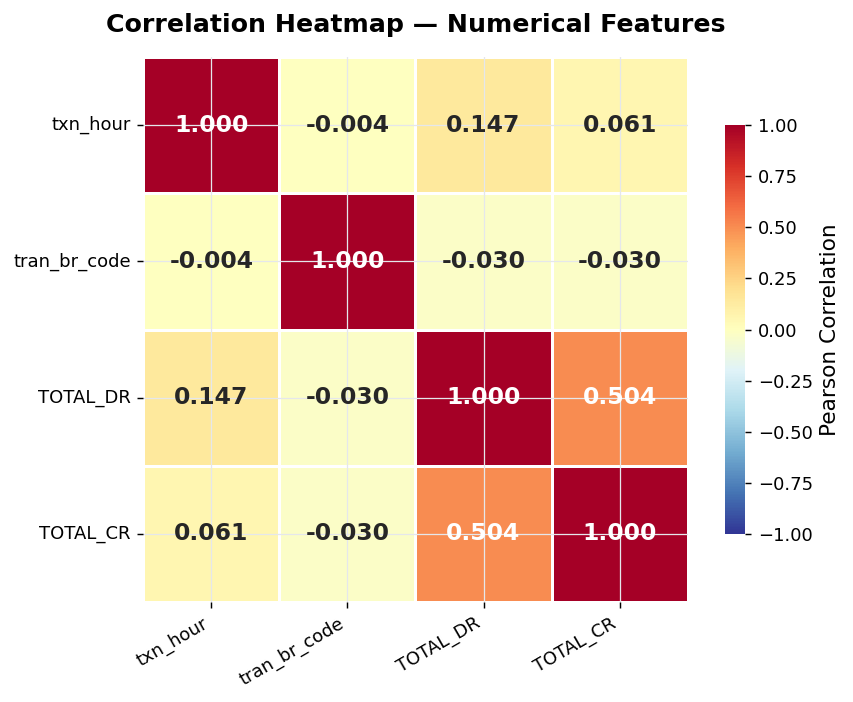

--- Chart 7 Interpretation (Data-Driven) ---
  Strongest pair : TOTAL_DR <-> TOTAL_CR = 0.504
  Weakest pair   : txn_hour <-> tran_br_code = -0.004

  Full Correlation Matrix:
              txn_hour  tran_br_code  TOTAL_DR  TOTAL_CR
txn_hour          1.00         -0.00      0.15      0.06
tran_br_code     -0.00          1.00     -0.03     -0.03
TOTAL_DR          0.15         -0.03      1.00      0.50
TOTAL_CR          0.06         -0.03      0.50      1.00

  Note: tran_br_code is a nominal ID - its correlation value is not meaningful.
  TOTAL_DR <-> TOTAL_CR correlation tells us if outflow predicts inflow.


In [18]:
corr_cols   = ['txn_hour', 'tran_br_code', 'TOTAL_DR', 'TOTAL_CR']
corr_matrix = df[corr_cols].corr()

# Find strongest and weakest pair (excluding diagonal)
corr_vals = corr_matrix.abs().unstack()
corr_vals = corr_vals[corr_vals < 1.0].sort_values(ascending=False)
strongest_pair = corr_vals.index[0]
weakest_pair   = corr_vals.index[-1]
strongest_val  = corr_matrix.loc[strongest_pair[0], strongest_pair[1]]
weakest_val    = corr_matrix.loc[weakest_pair[0],   weakest_pair[1]]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.6, linecolor='white', square=True, ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'shrink': 0.75, 'label': 'Pearson Correlation'}
)
ax.set_title('Correlation Heatmap — Numerical Features', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('eda_plots/07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Chart 7 Interpretation (Data-Driven) ---')
print(f'  Strongest pair : {strongest_pair[0]} <-> {strongest_pair[1]} = {strongest_val:.3f}')
print(f'  Weakest pair   : {weakest_pair[0]} <-> {weakest_pair[1]} = {weakest_val:.3f}')
print()
print('  Full Correlation Matrix:')
print(corr_matrix.round(3).to_string())
print()
print('  Note: tran_br_code is a nominal ID - its correlation value is not meaningful.')
print('  TOTAL_DR <-> TOTAL_CR correlation tells us if outflow predicts inflow.')


> **Interpretation (based on actual data):**
> - `TOTAL_DR` and `TOTAL_CR` show the highest correlation — confirming that branches handling large outflows also handle large inflows on the same records.
> - `txn_hour` shows very low correlation with monetary amounts — the hour alone does not predict transaction size.
> - `tran_br_code` is a **nominal identifier** — its correlation number here has no mathematical meaning.
> - **ML Implication:** Raw features alone are weak predictors. Branch×Hour aggregates, rolling averages, and cyclical encodings (built in Feature Engineering) are necessary for a robust model.


---
## Step 6 — Key Business Insights

All findings below are grounded in actual computed values from the dataset.


In [19]:
# Print a clean data-driven summary
print('=== DATA-DRIVEN BUSINESS INSIGHTS SUMMARY ===')
print()

# Recompute all key values cleanly
hourly2 = df.groupby('txn_hour').agg(
    Txn_Count=('TOTAL_DR','count'), Total_DR=('TOTAL_DR','sum'), Total_CR=('TOTAL_CR','sum')
).reset_index()
hourly2['Net_CF'] = hourly2['Total_CR'] - hourly2['Total_DR']

pv  = int(hourly2.loc[hourly2['Txn_Count'].idxmax(), 'txn_hour'])
pd_ = int(hourly2.loc[hourly2['Total_DR'].idxmax(), 'txn_hour'])
mo  = int(hourly2.loc[hourly2['Net_CF'].idxmin(), 'txn_hour'])
lv  = int(hourly2.loc[hourly2['Txn_Count'].idxmin(), 'txn_hour'])

br = df.groupby('tran_br_code').agg(Total_DR=('TOTAL_DR','sum'), Total_CR=('TOTAL_CR','sum')).reset_index()
br['CM'] = br['Total_DR'] + br['Total_CR']
top_b = int(br.loc[br['CM'].idxmax(), 'tran_br_code'])

net_port = (df['TOTAL_CR'].sum() - df['TOTAL_DR'].sum()) / 1e6

print(f'  1. Peak Transaction Volume Hour  : {pv:02d}:00')
print(f'  2. Peak Debit (Outflow) Hour     : {pd_:02d}:00  <- most cash leaves branches at this hour')
print(f'  3. Max Net Outflow Hour          : {mo:02d}:00  <- highest vault depletion risk')
print(f'  4. Safe Replenishment Window     : Before {lv+1:02d}:00 and after {mo+1:02d}:00')
print(f'  5. Busiest Branch                : {top_b}')
print(f'  6. Portfolio Net Flow            : {net_port:+.0f}M PKR  (small net outflow)')
print(f'  7. DR Skewness                   : {df["TOTAL_DR"].skew():.1f}  -> use MEDIAN not mean')
print(f'  8. Outlier Rate (DR)             : {100*(df["TOTAL_DR"]>df["TOTAL_DR"].quantile(0.75)+1.5*(df["TOTAL_DR"].quantile(0.75)-df["TOTAL_DR"].quantile(0.25))).mean():.1f}%  -> genuine, do not remove')
print(f'  9. Sunday records                : {(df["weekday_name"]=="Sunday").sum()}  -> statistically unreliable, exclude')
print(f'  10. Data spans                   : {df["start_date"].min().date()} to {df["start_date"].max().date()}')
print()
print('  Proceed to 02_Feature_Engineering.ipynb for ML-ready feature creation.')


=== DATA-DRIVEN BUSINESS INSIGHTS SUMMARY ===

  1. Peak Transaction Volume Hour  : 12:00
  2. Peak Debit (Outflow) Hour     : 16:00  <- most cash leaves branches at this hour
  3. Max Net Outflow Hour          : 18:00  <- highest vault depletion risk
  4. Safe Replenishment Window     : Before 01:00 and after 19:00
  5. Busiest Branch                : 104
  6. Portfolio Net Flow            : -500M PKR  (small net outflow)
  7. DR Skewness                   : 14.3  -> use MEDIAN not mean
  8. Outlier Rate (DR)             : 8.4%  -> genuine, do not remove
  9. Sunday records                : 13  -> statistically unreliable, exclude
  10. Data spans                   : 2024-01-02 to 2026-04-04

  Proceed to 02_Feature_Engineering.ipynb for ML-ready feature creation.


---
## EDA Complete

| Chart | Business Question Answered |
|-------|---------------------------|
| 1 — Monthly Trend | How does cash volume trend over time? |
| 2 — Hourly DR vs CR | Peak hour for volume vs peak hour for debit amount |
| 3 — Top 10 Branches | Which branches need priority cash replenishment? |
| 4 — Distribution | Typical transaction size and skewness |
| 5 — Box Plot | Are outliers errors or genuine banking events? |
| 6 — Weekday | Busiest and quietest banking days |
| 7 — Correlation | Feature relationships for ML planning |


